In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
order = "sleep	fars	adult	satimage	waveform_40	mfeat_fourier	yeast	german	horse_colic	cleve	prnn_synth	1203_BNG_pwLinear	1193_BNG_lowbwt	218_house_8L	537_houses	4544_GeographicalOriginalofMusic	598_fri_c0_1000_25	627_fri_c2_500_10	519_vinnie	695_chatfield_4	195_auto_price"
order = order.split("\t")
ensemble_result = json.load(open("flaml_ensemble_results.json"))
ensemble_result = pd.DataFrame(ensemble_result).T
ensemble_result = ensemble_result.loc[order]
ensemble_result.to_excel("flaml_ensemble_results.xlsx")

In [ ]:
results = pd.read_csv("results/results.CSV")
results

,dataset,Score_FLAML,Score_AzureML,Score_Databricks,Iterations_FLAML,Iterations_AzureML,Iterations_Databricks,TimeCost_FLAML,TimeCost_AzureML,TimeCost_Databricks,Efficiency_FLAML,Efficiency_AzureML,Efficiency_Databricks,BestAt_FLAML,BestAt_AzureML,BestAt_Databricks,n_lines,n_lines_log,n_feat,n_categorical_feat,n_continuous_feat,n_classes,imbalance,task,Unnamed: 24
0,sleep,0.7810,0.7775,0.7772,351,43,202,30,37,30,11.70,1.16,6.73,69,42,148,105908,5.02,13,0,13,5,1.480000e-01,classification,NaN
1,fars,0.8008,0.8014,0.7984,512,48,201,30,43,30,17.07,1.12,6.70,50,48,76,100968,5.00,29,29,0,8,1.560000e-01,classification,NaN
2,adult,0.8754,0.8733,0.8742,485,45,260,30,25,17,16.17,1.80,15.29,92,44,162,48842,4.69,14,7,6,2,2.720000e-01,classification,NaN
3,satimage,0.9130,0.9211,0.9068,582,43,200,30,32,15,19.40,1.34,13.33,102,42,101,6435,3.81,36,0,36,6,2.760000e-02,classification,NaN
4,waveform_40,0.8664,0.8704,0.8656,699,57,297,30,33,20,23.30,1.73,15.01,7,42,198,5000,3.70,40,0,40,3,5.790000e-05,classification,NaN
5,mfeat_fourier,0.8480,0.8320,0.7960,652,59,200,30,31,17,21.73,1.90,11.55,71,58,15,2000,3.30,76,0,76,10,0.000000e+00,classification,NaN
6,yeast,0.5946,0.6135,0.5865,711,45,200,30,33,14,23.70,1.36,14.29,140,44,38,1479,3.17,8,0,8,9,1.280000e-01,classification,NaN
7,german,0.7440,0.7240,0.7280,922,44,201,30,27,15,30.73,1.63,13.19,41,43,15,1000,3.00,20,11,7,2,1.600000e-01,classification,NaN
8,horse_colic,0.8043,0.8370,0.7609,792,55,200,30,36,8,26.40,1.53,25.00,22,55,200,368,2.57,22,21,0,2,6.810000e-02,classification,NaN
9,cleve,0.8026,0.8158,0.8158,948,44,251,30,24,18,31.60,1.83,13.95,57,43,152,303,2.48,13,5,5,2,7.940000e-03,classification,NaN


In [ ]:
cla_results = results[results["task"] == "classification"].reset_index(drop=True)
reg_results = results[results["task"] == "regression"].reset_index(drop=True)

In [ ]:
sns.set_theme(style="whitegrid")
def rolling_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w


def plt_nlines_analysis(results, wsize):
    x = results["n_lines_log"]
    sorted_idx = np.argsort(x)
    sorted_x = rolling_average(np.sort(x), wsize)
    sorted_frame = results.iloc[sorted_idx]
    FLAML_score = rolling_average(sorted_frame["Score_FLAML"], wsize)
    AML_score = rolling_average(sorted_frame["Score_AzureML"], wsize)
    DBX_score = rolling_average(sorted_frame["Score_Databricks"], wsize)
    plt.plot(sorted_x, FLAML_score, label="FLAML", color="red")
    plt.plot(sorted_x, AML_score, label="AzureML", color="orange")
    plt.plot(sorted_x, DBX_score, label="Databricks", color="green")
    plt.xlabel("lg(n_lines)")
    plt.ylabel("score")
    plt.title("n_lines dependant analysis")

def plt_nfeats_analysis(results, wsize):
    x = results["n_feat"]
    sorted_idx = np.argsort(x)
    sorted_x = rolling_average(np.sort(x), wsize)
    sorted_frame = results.iloc[sorted_idx]
    FLAML_score = rolling_average(sorted_frame["Score_FLAML"], wsize)
    AML_score = rolling_average(sorted_frame["Score_AzureML"], wsize)
    DBX_score = rolling_average(sorted_frame["Score_Databricks"], wsize)
    plt.plot(sorted_x, FLAML_score, label="FLAML", color="red")
    plt.plot(sorted_x, AML_score, label="AzureML", color="orange")
    plt.plot(sorted_x, DBX_score, label="Databricks", color="green")
    plt.xlabel("n_features")
    plt.ylabel("score")
    plt.title("n_feat dependant analysis")
    
def plt_nlines_performance(results, wsize):
    x = results["n_lines_log"]
    sorted_idx = np.argsort(x)
    sorted_x = rolling_average(np.sort(x), wsize)
    sorted_frame = results.iloc[sorted_idx]
    FLAML_score = rolling_average(sorted_frame["Iterations_FLAML"], wsize)
    AML_score = rolling_average(sorted_frame["Iterations_AzureML"], wsize)
    DBX_score = rolling_average(sorted_frame["Iterations_Databricks"], wsize)
    plt.plot(sorted_x, FLAML_score, label="FLAML", color="red")
    plt.plot(sorted_x, AML_score, label="AzureML", color="orange")
    plt.plot(sorted_x, DBX_score, label="Databricks", color="green")
    plt.xlabel("lg(n_lines))")
    plt.ylabel("iterations")
    plt.title("n_lines efficiency analysis")
    
def plt_nfeats_performance(results, wsize):
    x = results["n_feat"]
    sorted_idx = np.argsort(x)
    sorted_x = rolling_average(np.sort(x), wsize)
    sorted_frame = results.iloc[sorted_idx]
    FLAML_score = rolling_average(sorted_frame["Iterations_FLAML"], wsize)
    AML_score = rolling_average(sorted_frame["Iterations_AzureML"], wsize)
    DBX_score = rolling_average(sorted_frame["Iterations_Databricks"], wsize)
    plt.plot(sorted_x, FLAML_score, label="FLAML", color="red")
    plt.plot(sorted_x, AML_score, label="AzureML", color="orange")
    plt.plot(sorted_x, DBX_score, label="Databricks", color="green")
    plt.xlabel("n_features")
    plt.ylabel("iterations")
    plt.title("n_feat efficiency analysis")



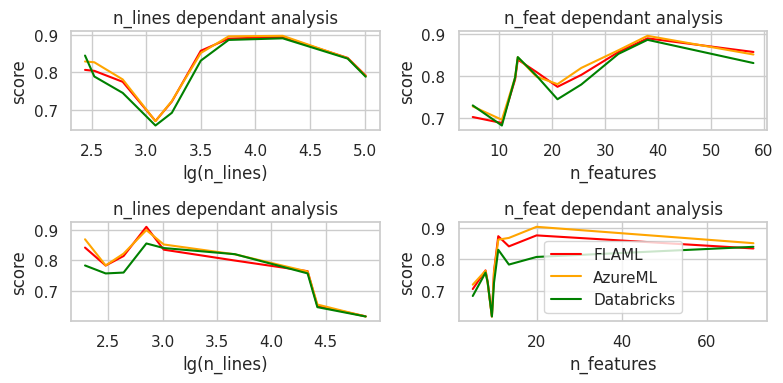

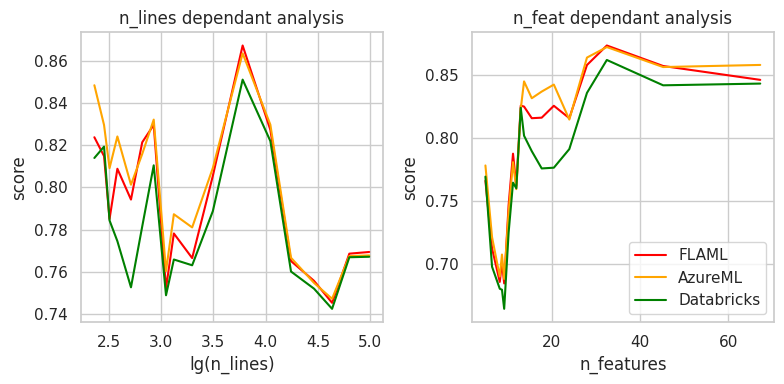

In [ ]:
plt.figure(figsize=(8, 4))
plt.subplot(2, 2, 1)
plt_nlines_analysis(cla_results, 2)
plt.subplot(2, 2, 2)
plt_nfeats_analysis(cla_results, 2)
plt.subplot(2, 2, 3)
plt_nlines_analysis(reg_results, 2)
plt.subplot(2, 2, 4)
plt_nfeats_analysis(reg_results, 2)
plt.tight_layout()
plt.legend()
# plt.savefig("images/dependant_analysis.svg", format="svg")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt_nlines_analysis(results, 4)
plt.subplot(1, 2, 2)
plt_nfeats_analysis(results, 4)
plt.tight_layout()
plt.legend()
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_3259198/3977924150.py:17: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 2, 1)


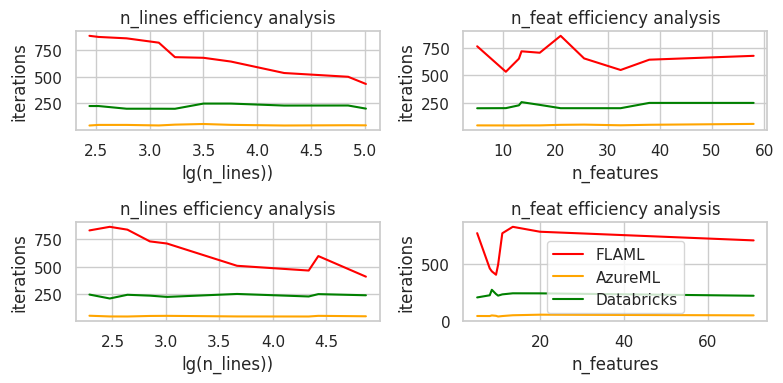

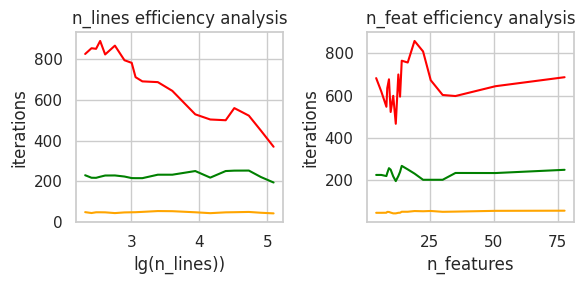

In [ ]:
plt.figure(figsize=(8, 4))
plt.subplot(2, 2, 1)
plt_nlines_performance(cla_results, 2)
plt.subplot(2, 2, 2)
plt_nfeats_performance(cla_results, 2)
plt.subplot(2, 2, 3)
plt_nlines_performance(reg_results, 2)
plt.subplot(2, 2, 4)
plt_nfeats_performance(reg_results, 2)
plt.tight_layout()
plt.legend()

# plt.savefig("images/performance_analysis.svg", format="svg")

plt.figure(figsize=(6, 3))
plt.legend()
plt.subplot(1, 2, 1)
plt_nlines_performance(results, 3)
plt.subplot(1, 2, 2)
plt_nfeats_performance(results, 3)
plt.tight_layout()
plt.show()


In [ ]:
choice_tasks = json.load(open("choice_tasks_v2.json"))
import pmlb
df_summary = pmlb.dataset_lists.df_summary
tasks = df_summary[df_summary['dataset'].isin([task["dataset"] for task in choice_tasks])]

reg_tasks = tasks[tasks["task"] == "regression"]
cla_tasks = tasks[tasks["task"] == "classification"]

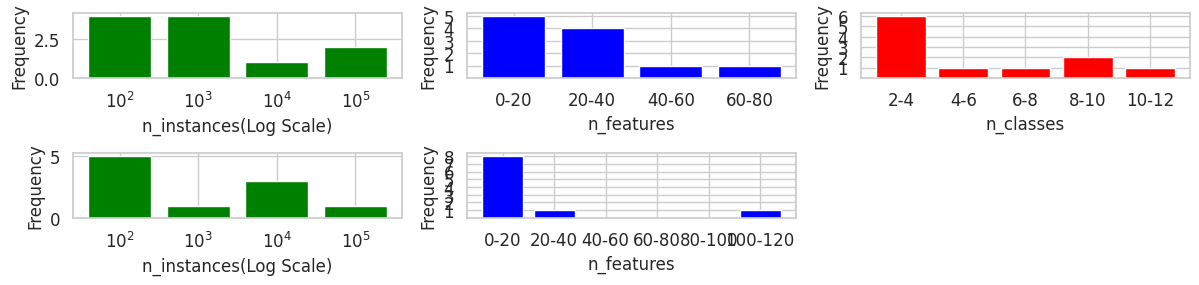

In [ ]:
sns.set_theme(style="whitegrid")
order = 1
def plt_bar_log(tasks, target_col, base=1):
    global order
    if target_col in ("imbalance", "n_classes"):
        choice = tasks[tasks['task'] == "classification"]
    else:
        choice = tasks
    arr = (np.log(choice[target_col]) / np.log(base)).astype('int') if base != 1 else choice[target_col]
    
    arr = arr.astype('int')
    xtick_range = np.arange(arr.min(), arr.max() + 1)
    if base != 1:
        xtick_labels = [f"${base}^{xtick}$" for xtick in xtick_range]
    else:
        xtick_labels = [f"{xtick}" for xtick in xtick_range]
    
    unique_values, counts = np.unique(arr, return_counts=True)
    plt.subplot(2, 3, order)
    fontsize=12
    plt.xticks(xtick_range, labels=xtick_labels, fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    plt.bar(unique_values, counts.astype('int'), color="green")
    plt.xlabel(target_col + "(Log Scale)", fontsize=fontsize)
    plt.ylabel("Frequency", fontsize=fontsize)
    order+=1


def plt_bar_div(tasks, target_col, base=1, color="blue"):
    global order
    if target_col in ("imbalance", "n_classes"):
        choice = tasks[tasks['task'] == "classification"]
    else:
        choice = tasks
    arr = choice[target_col] // base if base != 1 else choice[target_col]
    arr = arr.astype('int')
    xtick_range = np.arange(arr.min(), arr.max() + 1)
    xtick_labels = [f"{xtick * base}-{(xtick+1)*base}" for xtick in xtick_range]
    
    unique_values, counts = np.unique(arr, return_counts=True)
    plt.subplot(2, 3, order)
    fontsize=12
    plt.xticks(xtick_range, fontsize=fontsize,labels=xtick_labels, rotation=0)
    plt.yticks(np.arange(counts.min(), counts.max()+1), fontsize=fontsize)

    plt.bar(unique_values, counts.astype('int'), color=color)
    plt.xlabel(target_col, fontsize=fontsize)
    plt.ylabel("Frequency", fontsize=fontsize)
    order+=1
plt.figure(figsize=(12, 3))

plt_bar_log(cla_tasks, "n_instances", 10)
plt_bar_div(cla_tasks, "n_features", 20)
plt_bar_div(cla_tasks, "n_classes", 2, "red")

plt_bar_log(reg_tasks, "n_instances", 10)
plt_bar_div(reg_tasks, "n_features", 20)

plt.tight_layout()
# plt.savefig("images/dataset_analysis.svg", dpi=300,format="svg")
plt.show()



    

In [ ]:
dbx_runs_example = pd.read_csv("results/dbx_runs_sample.csv")

In [ ]:
flaml_runs_example = pd.read_csv("results/flaml_runs_example.csv")

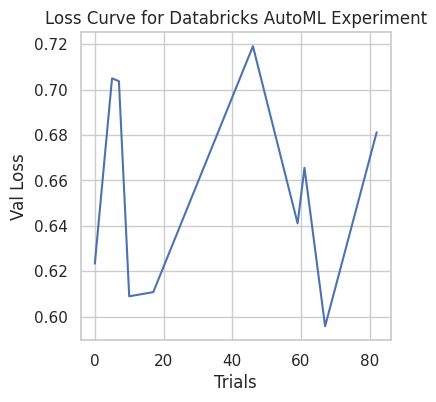

In [ ]:
def plot_dbx_runs_loss_curve(runs_example):
    selected_fields = ['Start Time', 'val_log_loss']
    frame = runs_example[selected_fields].copy()
    frame['Start Time'] = pd.to_datetime(frame['Start Time'])
    frame['timestamp'] = frame['Start Time'].astype('int64')
    frame = frame.sort_values(by=['timestamp']).head(10)
    frame['timestamp'] = (frame['timestamp'] - frame['timestamp'].min()) // 1000000000 
    plt.xlabel("Trials")
    plt.ylabel("Val Loss")
    plt.plot(frame['timestamp'], frame['val_log_loss'])
    plt.title("Loss Curve for Databricks AutoML Experiment")
    
plt.figure(figsize=(4, 4))
plot_dbx_runs_loss_curve(dbx_runs_example)
plt.show()


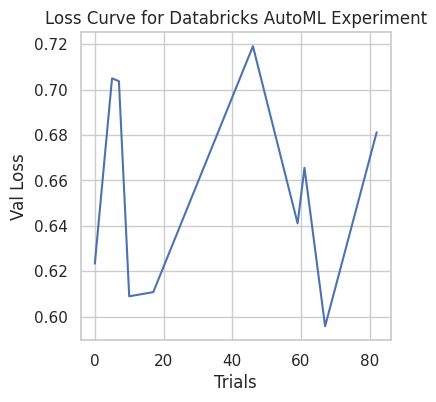

In [ ]:
def plot_flaml_runs_loss_curve(runs_example):
    selected_fields = ['Start Time', 'val_log_loss']
    frame = runs_example[selected_fields].copy()
    frame['Start Time'] = pd.to_datetime(frame['Start Time'])
    frame['timestamp'] = frame['Start Time'].astype('int64')
    frame = frame.sort_values(by=['timestamp']).head(10)
    frame['timestamp'] = (frame['timestamp'] - frame['timestamp'].min()) // 1000000000 
    plt.xlabel("Trials")
    plt.ylabel("Val Loss")
    plt.plot(frame['timestamp'], frame['val_log_loss'])
    plt.title("Loss Curve for Databricks AutoML Experiment")

plt.figure(figsize=(4, 4))
plot_dbx_runs_loss_curve(dbx_runs_example)
plt.show()